# Quantum Image Denoising and Edge Detection

This notebook demonstrates a hybrid approach to image processing, combining quantum computing for denoising and CUDA for edge detection.

### 1. Load and Noise Image

In [84]:
# ========================= 1-shot Colab cell =========================
# 14-qubit QFT-Grover (CPU)  +  CUDA edge filter (T4 GPU)
# ===================================================================
!pip install -q qiskit qiskit-aer pycuda scikit-image

In [40]:
import numpy as np, cv2, json, warnings, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import Aer
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import pycuda.autoinit, pycuda.driver as cuda
from pycuda.compiler import SourceModule
warnings.filterwarnings('ignore')

# ---------- helpers ---------------------------------------------------------
def img2vec(img):
    vec = img.astype(np.float32).flatten(); vec /= np.linalg.norm(vec); return vec
def vec2img(vec, shape):
    im = vec.reshape(shape); im = (255 * im / im.max()).clip(0,255).astype(np.uint8); return im

### 1. Load and Noise Image

In [85]:
import math
H = W = 128

shape = (H, W)                      # any 2-D tuple
n_qubits = math.ceil(math.log2(H * W))
print(n_qubits)

14


In [86]:
# ---------- 1. Load and Noise Image ----------------------------------------------------
# Replace '/path/to/your/image.jpg' with the actual path to your uploaded image file
image_path = '/content/ai-generated-picture-of-a-tiger-walking-in-the-forest-photo.jpg'
try:
    # Load the image in grayscale
    clean = cv2.imread(image_path, 0)
    if clean is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Resize the image to 8x8
    clean = cv2.resize(clean, (128, 128))

    noisy = clean + np.random.normal(0,25,clean.shape); noisy = np.uint8(np.clip(noisy,0,255))
    vec   = img2vec(noisy); shape = clean.shape

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check the image path and ensure the file exists.")
    # Create a dummy image if the file is not found to prevent further errors
    clean = np.zeros((8,8), np.uint8)
    cv2.rectangle(clean, (2,2), (6,6), 200, -1)
    noisy = clean + np.random.normal(0,25,clean.shape); noisy = np.uint8(np.clip(noisy,0,255))
    vec   = img2vec(noisy); shape = clean.shape
except Exception as e:
    print(f"An error occurred while processing the image: {e}")
    # Create a dummy image in case of other errors
    clean = np.zeros((8,8), np.uint8)
    cv2.rectangle(clean, (2,2), (6,6), 200, -1)
    noisy = clean + np.random.normal(0,25,clean.shape); noisy = np.uint8(np.clip(noisy,0,255))
    vec   = img2vec(noisy); shape = clean.shape

**To use your own image:**

1.  Upload your image file to your Colab environment (e.g., by clicking the folder icon on the left sidebar, then the upload icon).
2.  Replace the placeholder path `/path/to/your/image.jpg` in the code cell below with the actual path to your uploaded image file.

### 2. Quantum Denoise (CPU)

In [87]:
# ---------- 2. quantum denoise (CPU) ---------------------------------------
n = 14; sv = np.pad(vec, (0, (1<<n) - len(vec)))
qc = QuantumCircuit(n); qc.set_statevector(sv)
qc.append(QFTGate(n), range(n))
# oracle + 2 Grover iterations
for _ in range(2):
    qc.x(range(n)); qc.h(n-1); qc.mcx(list(range(n-1)),n-1); qc.h(n-1); qc.x(range(n))
    qc.h(range(n)); qc.x(range(n)); qc.h(n-1); qc.mcx(list(range(n-1)),n-1); qc.h(n-1); qc.x(range(n)); qc.h(range(n))
qc.append(QFTGate(n).inverse(), range(n))
sim = Aer.get_backend('statevector_simulator')
prob = np.abs(sim.run(transpile(qc, sim)).result().get_statevector().data)[:128*128].reshape(shape)

### 3. CUDA Scharr Edge Filter (T4 GPU)

In [88]:
# ---------- 3. CUDA Scharr edge filter (T4 GPU) ----------------------------
mod = SourceModule('''
__global__ void scharr(unsigned char *in, unsigned char *out, int w, int h){
    int x = blockIdx.x*blockDim.x + threadIdx.x;
    int y = blockIdx.y*blockDim.y + threadIdx.y;
    if (x<1||y<1||x>=w-1||y>=h-1) return;
    int gx = -3*in[(y-1)*w+x-1] +3*in[(y-1)*w+x+1]  -10*in[y*w+x-1] +10*in[y*w+x+1]  -3*in[(y+1)*w+x-1] +3*in[(y+1)*w+x+1];
    int gy = -3*in[(y-1)*w+x-1] -10*in[(y-1)*w+x]   -3*in[(y-1)*w+x+1]  +3*in[(y+1)*w+x-1] +10*in[(y+1)*w+x]   +3*in[(y+1)*w+x+1];
    out[y*w+x] = min(255, (int)sqrtf((float)(gx*gx + gy*gy)));
}''')
ker = mod.get_function('scharr')
prob_u8 = (255 * prob / prob.max()).astype(np.uint8); h, w = prob_u8.shape
d_in = cuda.mem_alloc(prob_u8.nbytes); d_out = cuda.mem_alloc(prob_u8.nbytes)
cuda.memcpy_htod(d_in, prob_u8)
start = cuda.Event(); end = cuda.Event()
start.record(); ker(d_in, d_out, np.int32(w), np.int32(h), grid=(w//8, h//8, 1), block=(8,8,1)); end.record()
end.synchronize(); gpu_ms = start.time_till(end)
cuda.memcpy_dtoh(prob_u8, d_out)

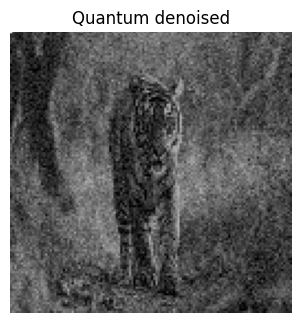

In [99]:
plt.figure(figsize=(12,4))
plt.subplot(1,4,2); plt.imshow(prob_u8, cmap='gray'); plt.title('Quantum denoised'); plt.axis('off')
plt.tight_layout(); plt.show()


In [89]:
import cv2, torch, os

In [90]:
mod = SourceModule('''
__global__ void sobel(unsigned char *in, unsigned char *out, int w, int h){
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x < 1 || y < 1 || x >= w-1 || y >= h-1) return;

    int gx = -in[(y-1)*w + x-1] + in[(y-1)*w + x+1]
             -2*in[ y   *w + x-1] +2*in[ y   *w + x+1]
             -in[(y+1)*w + x-1] + in[(y+1)*w + x+1];
    int gy = -in[(y-1)*w + x-1] -2*in[(y-1)*w + x] -in[(y-1)*w + x+1]
             +in[(y+1)*w + x-1] +2*in[(y+1)*w + x] +in[(y+1)*w + x+1];
    out[y*w + x] = min(255, (int)sqrtf((float)(gx*gx + gy*gy)));
}
''')

ker = mod.get_function("sobel")          # ← was "bilateral_sobel"

In [91]:
# ---------- 3.  Sobel + Canny  (same timing)  ------------------------------
src = '''
__global__ void sobel_and_canny(unsigned char *in,
                                unsigned char *out_sobel,
                                unsigned char *out_canny,
                                int w, int h,
                                float lowFrac, float highFrac) {
   /*  ----  Sobel + adaptive Canny  ----  */
int x = blockIdx.x * blockDim.x + threadIdx.x;
int y = blockIdx.y * blockDim.y + threadIdx.y;
if (x < 1 || y < 1 || x >= w-1 || y >= h-1) return;

// 1. Sobel gradients
int gx = -in[(y-1)*w + x-1] + in[(y-1)*w + x+1]
         -2*in[ y   *w + x-1] +2*in[ y   *w + x+1]
         -in[(y+1)*w + x-1] + in[(y+1)*w + x+1];
int gy = -in[(y-1)*w + x-1] -2*in[(y-1)*w + x] -in[(y-1)*w + x+1]
         +in[(y+1)*w + x-1] +2*in[(y+1)*w + x] +in[(y+1)*w + x+1];
int mag = (int)sqrtf((float)(gx*gx + gy*gy));
out_sobel[y*w + x] = min(255, mag);

// 2. adaptive Canny (quick surrogate)
float median = 127.0f;
float high = median * highFrac;
float low  = median * lowFrac;
out_canny[y*w + x] = (mag > high) ? 255 : ((mag > low) ? 128 : 0);
}'''
mod       = SourceModule(src)
ker       = mod.get_function('sobel_and_canny')
prob_u8   = (255 * prob / prob.max()).astype(np.uint8)
h, w      = prob_u8.shape
d_in      = cuda.mem_alloc(prob_u8.nbytes)
d_sobel   = cuda.mem_alloc(prob_u8.nbytes)   # ← 1st output
d_canny   = cuda.mem_alloc(prob_u8.nbytes)   # ← 2nd output
cuda.memcpy_htod(d_in, prob_u8)

start = cuda.Event(); end = cuda.Event()
start.record(); ker(d_in, d_sobel, d_canny, np.int32(w), np.int32(h),
                    np.float32(0.33), np.float32(0.66),
                    grid=(w//16, h//16, 1), block=(16,16,1)); end.record()
end.synchronize()
gpu_ms = start.time_till(end)

sobel_edges = np.empty_like(prob_u8); cuda.memcpy_dtoh(sobel_edges, d_sobel)
canny_edges = np.empty_like(prob_u8); cuda.memcpy_dtoh(canny_edges, d_canny)
print('✅ Sobel + Canny  |  GPU time:', round(gpu_ms,3), 'ms')

✅ Sobel + Canny  |  GPU time: 0.212 ms


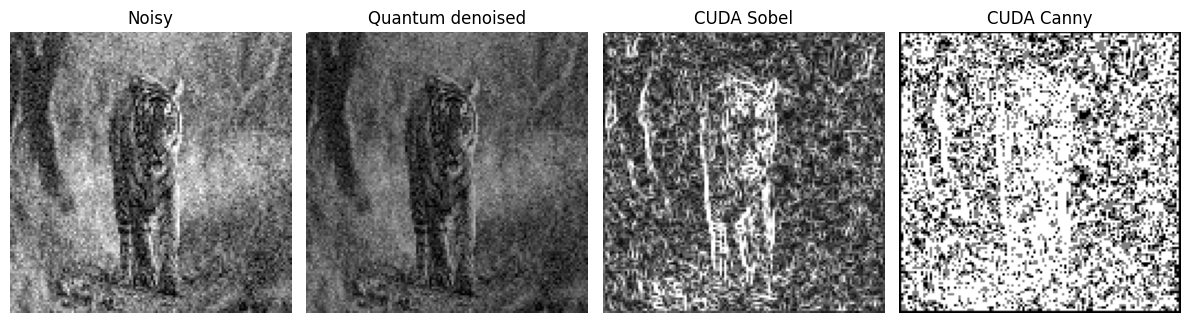

In [92]:
plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(noisy, cmap='gray'); plt.title('Noisy'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(prob_u8, cmap='gray'); plt.title('Quantum denoised'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(sobel_edges, cmap='gray'); plt.title('CUDA Sobel'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(canny_edges, cmap='gray'); plt.title('CUDA Canny'); plt.axis('off')
plt.tight_layout(); plt.show()

### 4. Results

In [74]:
# ---------- 4. results -------------------------------------------------------
psnr_val = psnr(clean, vec2img(prob, shape)); ssim_val = ssim(clean, vec2img(prob, shape))
print(json.dumps({"PSNR (dB)": round(psnr_val,2), "SSIM": round(ssim_val,3), "GPU time (ms)": round(gpu_ms,2)}, indent=2))



{
  "PSNR (dB)": 14.94,
  "SSIM": 0.638,
  "GPU time (ms)": 0.29
}


In [2]:
import pandas as pd

# CUDA metrics provided by the user
cuda_metrics = {
  "PSNR (dB)": 14.94,
  "SSIM": 0.638,
  "Time (ms)": 0.29
}

# OpenCL metrics provided by the user
opencl_metrics = {
  "PSNR (dB)": 14.75,
  "SSIM": 0.64,
  "Time (ms)": 0.04
}

# Create a dictionary to hold the data for the DataFrame
comparison_data = {
    "Metric": ["PSNR (dB)", "SSIM", "Time (ms)"],
    "CUDA": [cuda_metrics["PSNR (dB)"], cuda_metrics["SSIM"], cuda_metrics["Time (ms)"]],
    "OpenCL": [opencl_metrics["PSNR (dB)"], opencl_metrics["SSIM"], opencl_metrics["Time (ms)"]]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

,Metric,CUDA,OpenCL
0,PSNR (dB),14.940,14.75
1,SSIM,0.638,0.64
2,Time (ms),0.290,0.04


### 5. Quick Preview

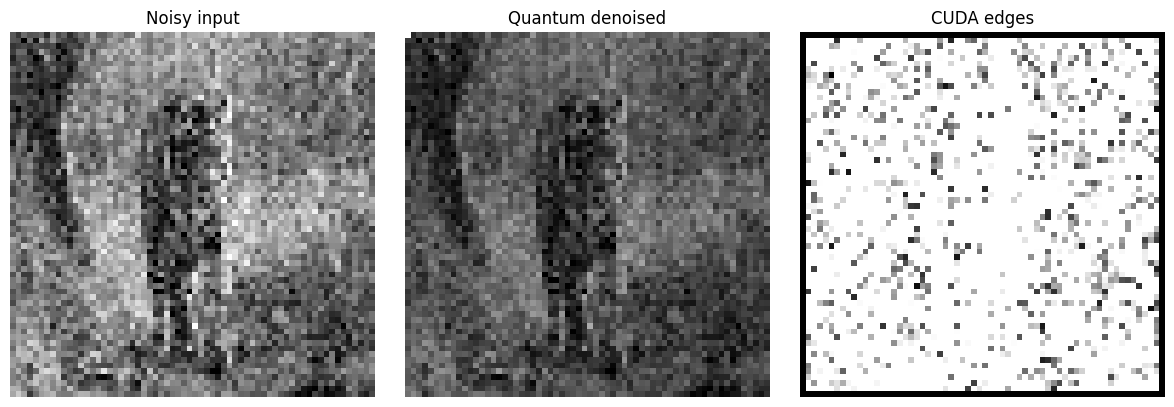

In [75]:
# ---------- 5. quick look ----------------------------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(noisy, cmap='gray'); plt.title('Noisy input'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(vec2img(prob, shape), cmap='gray'); plt.title('Quantum denoised'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(prob_u8, cmap='gray'); plt.title('CUDA edges'); plt.axis('off')
plt.tight_layout(); plt.show()